# Random Forest

### Overview
- [Setup and Data Loading](#Setup-and-Data-Loading)
- [Encoding the Features](#Encoding-the-Features)
- [The Majority Baseline](#The-Majority-Baseline)
- [From a Single Tree to a Forest (variance reduction)](#From-a-Single-Tree-to-a-Forest-(variance-reduction))
- [A Random Forest from a Parameter Guess](#A-Random-Forest-from-a-Parameter-Guess)
- [Tuning the Random Forest](#Tuning-the-Random-Forest)
- [Feature Importances](#Feature-Importances)
- [Final Evaluation and the Imbalance Effect](#Final-Evaluation-and-the-Imbalance-Effect)
- [Saving the Results](#Saving-the-Results)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix # evaluation metrics

## Setup and Data Loading

The train/test split was produced in the preprocessing phase and stored in `data/processed/`.
Two scopes of the data are available. The primary one is `scope_2000_2018`; the `SCOPE` variable is used for ease of comparison between the two.

In [2]:
SCOPE = "scope_2000_2018"
DATA_DIR = "data/processed/" + SCOPE

X_train = pd.read_csv(DATA_DIR + "/X_train.csv")
X_test  = pd.read_csv(DATA_DIR + "/X_test.csv")
y_train = pd.read_csv(DATA_DIR + "/y_train.csv")["Hit"]
y_test  = pd.read_csv(DATA_DIR + "/y_test.csv")["Hit"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print('Hit  (1):', len(y_train[y_train==1]) / len(y_train))
print('Flop (0):', len(y_train[y_train==0]) / len(y_train))

X_train shape: (13681, 3)
X_test shape:  (3421, 3)
Hit  (1): 0.2034938966449821
Flop (0): 0.7965061033550179


Same ~80/20 imbalance, so ROC-AUC, F1 and the confusion matrix are used, not accuracy alone.

## Encoding the Features

Same as the Decision Tree: `genre` and `platform_family` are one-hot encoded, `publisher_tier` stays numeric. Train and test are column-aligned.

In [3]:
cat_cols = ['genre', 'platform_family'] # nominal -> OHE

X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print('Number of features after one-hot encoding:', X_train_enc.shape[1])
X_train_enc.head()

Number of features after one-hot encoding: 21


,publisher_tier,genre_Action,genre_Action-Adventure,genre_Adventure,genre_Fighting,genre_Misc,genre_Music,genre_Platform,genre_Puzzle,genre_Racing,...,genre_Shooter,genre_Simulation,genre_Sports,genre_Strategy,genre_Visual Novel,platform_family_Nintendo,platform_family_Other,platform_family_PC,platform_family_PlayStation,platform_family_Xbox
0,2,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,2,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,2,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## The Majority Baseline

The reference to beat: always predict the majority class (Flop = `0`).

In [4]:
# always predict flop
baseline_pred = np.zeros(len(y_test), dtype=int)
print('Majority baseline accuracy:', accuracy_score(y_test, baseline_pred))
print('Majority baseline F1      :', f1_score(y_test, baseline_pred, zero_division=0))
print('Majority baseline ROC-AUC : 0.5 (constant prediction)')

Majority baseline accuracy: 0.7965507161648641
Majority baseline F1      : 0.0
Majority baseline ROC-AUC : 0.5 (constant prediction)


## From a Single Tree to a Forest

A single unpruned tree typically overfits.

In [16]:
# single unpruned tree
single_tree = DecisionTreeClassifier(criterion='entropy',
                                     max_depth=None,
                                     random_state=1)
single_tree = single_tree.fit(X_train_enc, y_train)
print('Single tree   train/test accuracy: %.3f / %.3f' % (
    accuracy_score(y_train, single_tree.predict(X_train_enc)),
    accuracy_score(y_test,  single_tree.predict(X_test_enc))))

# forest
forest = RandomForestClassifier(criterion='entropy',
                                n_estimators=100,
                                max_features='sqrt',
                                random_state=1,
                                n_jobs=-1)
forest = forest.fit(X_train_enc, y_train)
print('Random forest train/test accuracy: %.3f / %.3f' % (
    accuracy_score(y_train, forest.predict(X_train_enc)),
    accuracy_score(y_test,  forest.predict(X_test_enc))))

Single tree   train/test accuracy: 0.804 / 0.799
Random forest train/test accuracy: 0.804 / 0.799


No gap, same reason as the decision tree.

## A Random Forest from a Parameter Guess

A first forest with hand-picked parameters:

- `n_estimators` — number of trees (100–500),
- `max_features='sqrt'` — features considered per split,
- `max_samples` — bootstrap size (`None` = training-set size),
- `max_depth` — small trees are common in forests,
- `criterion` — gini or entropy.

Scored on the test set:

In [6]:
forest = RandomForestClassifier(criterion='gini',
                                n_estimators=100,
                                max_samples=None,  # bootstrap size = dataset size
                                max_features='sqrt',
                                max_depth=5,
                                random_state=1,
                                n_jobs=-1)
forest.fit(X_train_enc, y_train)

pred = forest.predict(X_test_enc)
print('Test accuracy:', accuracy_score(y_test, pred))
print('Test f1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, forest.predict_proba(X_test_enc)[:,1]))

Test accuracy: 0.7965507161648641
Test f1      : 0.0
Test ROC-AUC : 0.7781538015395972


With `max_depth=5` the forest is so conservative it predicts Flop for every game (F1 = 0), even though its ROC-AUC is already ~0.78.

## Tuning the Random Forest



In [7]:
param_grid = {'n_estimators': np.array([100, 250]),
              'criterion': ['gini', 'entropy'],
              'max_depth': [3, 5, 7, None]}

forest = RandomForestClassifier(max_features='sqrt',
                                random_state=1,
                                n_jobs=-1)

forest_cv = GridSearchCV(forest, param_grid, scoring='roc_auc', cv=5,
                         verbose=1, n_jobs=-1, refit=True)
forest_cv.fit(X_train_enc, y_train)

print('Best CV ROC-AUC:', forest_cv.best_score_)
print('Best parameters:', forest_cv.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV ROC-AUC: 0.7743364169828476
Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': np.int64(250)}


In [8]:
best_forest = forest_cv.best_estimator_
pred = best_forest.predict(X_test_enc)

print('Test accuracy:', accuracy_score(y_test, pred))
print('Test f1      :', f1_score(y_test, pred))
print('Test ROC-AUC :', roc_auc_score(y_test, best_forest.predict_proba(X_test_enc)[:,1]))

Test accuracy: 0.7983045893013738
Test f1      : 0.08
Test ROC-AUC : 0.7826671412000421


The best parameters are kept as the final config and stored, so the same forest can be rebuilt on the down-sampled data below:

In [9]:
best_params = forest_cv.best_params_
print('final forest parameters:', best_params)

def fit_forest(X_tr, y_tr):
    # rebuild forest with tuned params
    rf = RandomForestClassifier(max_features='sqrt', random_state=1, n_jobs=-1,
                                **best_params)
    rf.fit(X_tr, y_tr)
    return rf

final forest parameters: {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': np.int64(250)}


## Feature Importances



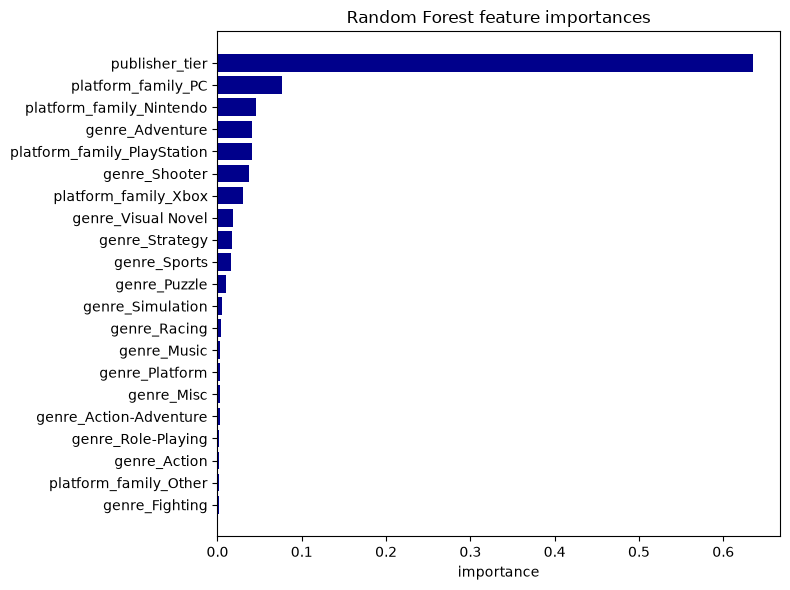

In [10]:
importances = pd.Series(best_forest.feature_importances_, index=X_train_enc.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values, color='darkblue')
plt.title('Random Forest feature importances')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

About 66% publisher tier. 

## Final Evaluation and the Imbalance Effect

The final forest is run twice: as-is (`resample = none`) and on a 50/50 down-sampled training set (`resample = downsample`). The `evaluate` helper prints the three metrics and the confusion matrix and returns one result row.

In [11]:
def evaluate(model, X_te, y_te, model_name, resample):
    proba = model.predict_proba(X_te)[:, 1] # prob of Hit
    pred  = model.predict(X_te)
    roc = roc_auc_score(y_te, proba)
    f1  = f1_score(y_te, pred)
    acc = accuracy_score(y_te, pred)
    print('--- %s (resample=%s) ---' % (model_name, resample))
    print('ROC-AUC : %.3f' % roc)
    print('F1      : %.3f' % f1)
    print('Accuracy: %.3f' % acc)
    print('Confusion matrix [rows = true 0/1, cols = predicted 0/1]:')
    print(confusion_matrix(y_te, pred))
    return {'model': model_name, 'resample': resample,
            'roc_auc': roc, 'f1': f1, 'accuracy': acc}

### Run 1 — no resampling

In [12]:
forest_none = fit_forest(X_train_enc, y_train)
row_none = evaluate(forest_none, X_test_enc, y_test, 'random_forest', 'none')

--- random_forest (resample=none) ---
ROC-AUC : 0.783
F1      : 0.080
Accuracy: 0.798
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[2701   24]
 [ 666   30]]


### Run 2 — 50/50 down-sampling

The majority class is down-sampled to the number of Hits; only the training data is balanced.

In [13]:
# split by class
train = X_train_enc.copy()
train['Hit'] = y_train.values

hits  = train[train['Hit'] == 1]
flops = train[train['Hit'] == 0]

# downsample flops to the number of hits
flops_down = flops.sample(n=len(hits), random_state=0)

train_bal = pd.concat([hits, flops_down]).sample(frac=1, random_state=0) # shuffle
X_train_bal = train_bal.drop(columns='Hit')
y_train_bal = train_bal['Hit']

print('Balanced training set size:', len(y_train_bal))
print('Hit  (1):', len(y_train_bal[y_train_bal == 1]))
print('Flop (0):', len(y_train_bal[y_train_bal == 0]))

Balanced training set size: 5568
Hit  (1): 2784
Flop (0): 2784


In [14]:
forest_bal = fit_forest(X_train_bal, y_train_bal)
row_down = evaluate(forest_bal, X_test_enc, y_test, 'random_forest', 'downsample')

--- random_forest (resample=downsample) ---
ROC-AUC : 0.781
F1      : 0.495
Accuracy: 0.640
Confusion matrix [rows = true 0/1, cols = predicted 0/1]:
[[1585 1140]
 [  92  604]]


Without resampling the forest is very conservative: it predicts Hit for only 54 games and finds just 30 of 696 real hits (F1 = 0.08, worse than the single tree). Down-sampling raises that to 604 of 696 hits found (F1 = 0.50), at the cost of accuracy, while ROC-AUC stays ~0.78. The imbalance effect is even stronger here than for the decision tree.

## Saving the Results

Saved with columns `model, resample, roc_auc, f1, accuracy`.

In [15]:
os.makedirs('results', exist_ok=True)

results = pd.DataFrame([row_none, row_down])
results = results[['model', 'resample', 'roc_auc', 'f1', 'accuracy']]

# for comparison only
if SCOPE == 'scope_2000_2018':
    out_path = 'results/random_forest.csv'
else:
    out_path = 'results/random_forest_' + SCOPE + '.csv'

results.to_csv(out_path, index=False)
print('Saved', out_path)
results

Saved results/random_forest.csv


,model,resample,roc_auc,f1,accuracy
0,random_forest,none,0.782667,0.080000,0.798305
1,random_forest,downsample,0.780825,0.495082,0.639871
